In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('NVIDIA_STOCK.csv')
df.head()

,Price,Adj Close,Close,High,Low,Open,Volume
0,Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,NVDA
1,Date,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-01-02,4.929879665374756,4.983749866485596,4.987500190734863,4.862500190734863,4.894499778747559,355616000
3,2018-01-03,5.254334926605225,5.3117499351501465,5.34250020980835,5.09375,5.102499961853027,914704000
4,2018-01-04,5.2820329666137695,5.339749813079834,5.451250076293945,5.317249774932861,5.394000053405762,583268000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1699 entries, 0 to 1698
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1699 non-null   object
 1   Adj Close  1698 non-null   object
 2   Close      1698 non-null   object
 3   High       1698 non-null   object
 4   Low        1698 non-null   object
 5   Open       1698 non-null   object
 6   Volume     1698 non-null   object
dtypes: object(7)
memory usage: 93.0+ KB


In [6]:
df = df.iloc[2:].reset_index(drop=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1697 entries, 0 to 1696
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1697 non-null   object
 1   Adj Close  1697 non-null   object
 2   Close      1697 non-null   object
 3   High       1697 non-null   object
 4   Low        1697 non-null   object
 5   Open       1697 non-null   object
 6   Volume     1697 non-null   object
dtypes: object(7)
memory usage: 92.9+ KB


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.shape

(1697, 7)

In [10]:
df.head()

,Price,Adj Close,Close,High,Low,Open,Volume
0,2018-01-02,4.929879665374756,4.983749866485596,4.987500190734863,4.862500190734863,4.894499778747559,355616000
1,2018-01-03,5.254334926605225,5.3117499351501465,5.34250020980835,5.09375,5.102499961853027,914704000
2,2018-01-04,5.2820329666137695,5.339749813079834,5.451250076293945,5.317249774932861,5.394000053405762,583268000
3,2018-01-05,5.326793670654297,5.385000228881836,5.422749996185303,5.2769999504089355,5.354750156402588,580124000
4,2018-01-08,5.490012168884277,5.550000190734863,5.625,5.4644999504089355,5.510000228881836,881216000


In [11]:
df.head()

,Price,Adj Close,Close,High,Low,Open,Volume
0,2018-01-02,4.929879665374756,4.983749866485596,4.987500190734863,4.862500190734863,4.894499778747559,355616000
1,2018-01-03,5.254334926605225,5.3117499351501465,5.34250020980835,5.09375,5.102499961853027,914704000
2,2018-01-04,5.2820329666137695,5.339749813079834,5.451250076293945,5.317249774932861,5.394000053405762,583268000
3,2018-01-05,5.326793670654297,5.385000228881836,5.422749996185303,5.2769999504089355,5.354750156402588,580124000
4,2018-01-08,5.490012168884277,5.550000190734863,5.625,5.4644999504089355,5.510000228881836,881216000


In [12]:
df.columns = ["Date", "Adj Close", "Close", "High", "Low", "Open", "Volume"]

In [13]:
df['Date'] = pd.to_datetime(df['Date'])

numeric_cols = ["Adj Close", "Close", "High", "Low", "Open", "Volume"]
df[numeric_cols] = df[numeric_cols].astype(float)

In [14]:
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2018-01-02,4.929880,4.98375,4.98750,4.86250,4.89450,355616000.0
1,2018-01-03,5.254335,5.31175,5.34250,5.09375,5.10250,914704000.0
2,2018-01-04,5.282033,5.33975,5.45125,5.31725,5.39400,583268000.0
3,2018-01-05,5.326794,5.38500,5.42275,5.27700,5.35475,580124000.0
4,2018-01-08,5.490012,5.55000,5.62500,5.46450,5.51000,881216000.0


In [15]:
df = df.sort_values("Date")
df.set_index("Date", inplace=True)

In [16]:
df.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2018-01-02,4.929880,4.98375,4.98750,4.86250,4.89450,355616000.0
2018-01-03,5.254335,5.31175,5.34250,5.09375,5.10250,914704000.0
2018-01-04,5.282033,5.33975,5.45125,5.31725,5.39400,583268000.0
2018-01-05,5.326794,5.38500,5.42275,5.27700,5.35475,580124000.0
2018-01-08,5.490012,5.55000,5.62500,5.46450,5.51000,881216000.0


In [17]:
df["day_of_week"] = df.index.dayofweek      # 0 = Monday
df["month"] = df.index.month
df["day"] = df.index.day
df["week_of_year"] = df.index.isocalendar().week.astype(int)

In [18]:
df.head()

,Adj Close,Close,High,Low,Open,Volume,day_of_week,month,day,week_of_year
Date,,,,,,,,,,
2018-01-02,4.929880,4.98375,4.98750,4.86250,4.89450,355616000.0,1,1,2,1
2018-01-03,5.254335,5.31175,5.34250,5.09375,5.10250,914704000.0,2,1,3,1
2018-01-04,5.282033,5.33975,5.45125,5.31725,5.39400,583268000.0,3,1,4,1
2018-01-05,5.326794,5.38500,5.42275,5.27700,5.35475,580124000.0,4,1,5,1
2018-01-08,5.490012,5.55000,5.62500,5.46450,5.51000,881216000.0,0,1,8,2


In [20]:
df["return"] = df["Close"].pct_change()

In [21]:
df["volatility"] = df["return"].rolling(20).std()

In [22]:
df.dropna(inplace=True)

In [23]:
df.head()

,Adj Close,Close,High,Low,Open,Volume,day_of_week,month,day,week_of_year,return,volatility
Date,,,,,,,,,,,,
2018-01-31,6.078580,6.1450,6.23175,6.11125,6.14425,4.785760e+08,2,1,31,5,0.012690,0.018992
2018-02-01,5.947512,6.0125,6.17250,5.95150,5.96300,5.192240e+08,3,2,1,5,-0.021562,0.015345
2018-02-02,5.774898,5.8380,5.94925,5.77925,5.92500,7.184640e+08,4,2,2,5,-0.029023,0.017265
2018-02-05,5.284754,5.3425,5.83075,5.12500,5.67500,1.165204e+09,0,2,5,6,-0.084875,0.026379
2018-02-06,5.578543,5.6395,5.64250,5.10000,5.11000,1.114800e+09,1,2,6,6,0.055592,0.028418


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1677 entries, 2018-01-31 to 2024-09-30
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Adj Close     1677 non-null   float64
 1   Close         1677 non-null   float64
 2   High          1677 non-null   float64
 3   Low           1677 non-null   float64
 4   Open          1677 non-null   float64
 5   Volume        1677 non-null   float64
 6   day_of_week   1677 non-null   int32  
 7   month         1677 non-null   int32  
 8   day           1677 non-null   int32  
 9   week_of_year  1677 non-null   int64  
 10  return        1677 non-null   float64
 11  volatility    1677 non-null   float64
dtypes: float64(8), int32(3), int64(1)
memory usage: 150.7 KB


In [25]:
threshold = df['volatility'].quantile(0.90)
df['target'] = (df['volatility'].shift(-1) > threshold).astype(int)
df.dropna(inplace=True)

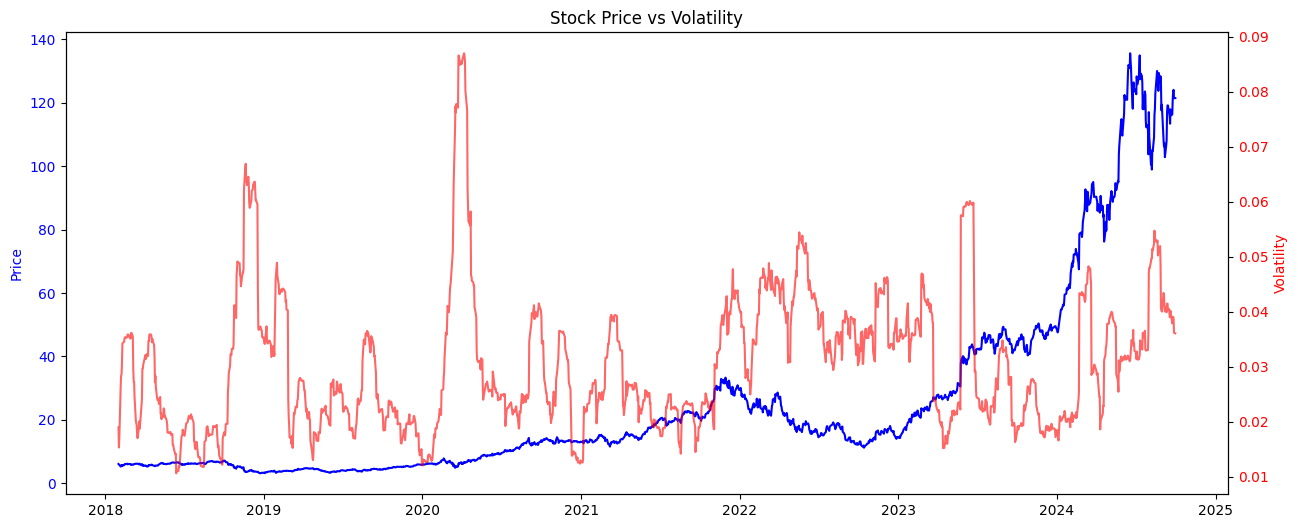

In [31]:
# Price + Volatility
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(15,6))

# Price
ax1.plot(df.index, df["Adj Close"], color="blue", label="Adj Close")
ax1.set_ylabel("Price", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# Volatility
ax2 = ax1.twinx()
ax2.plot(df.index, df["volatility"], color="red", alpha=0.6, label="Volatility")
ax2.set_ylabel("Volatility", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Stock Price vs Volatility")
plt.show()

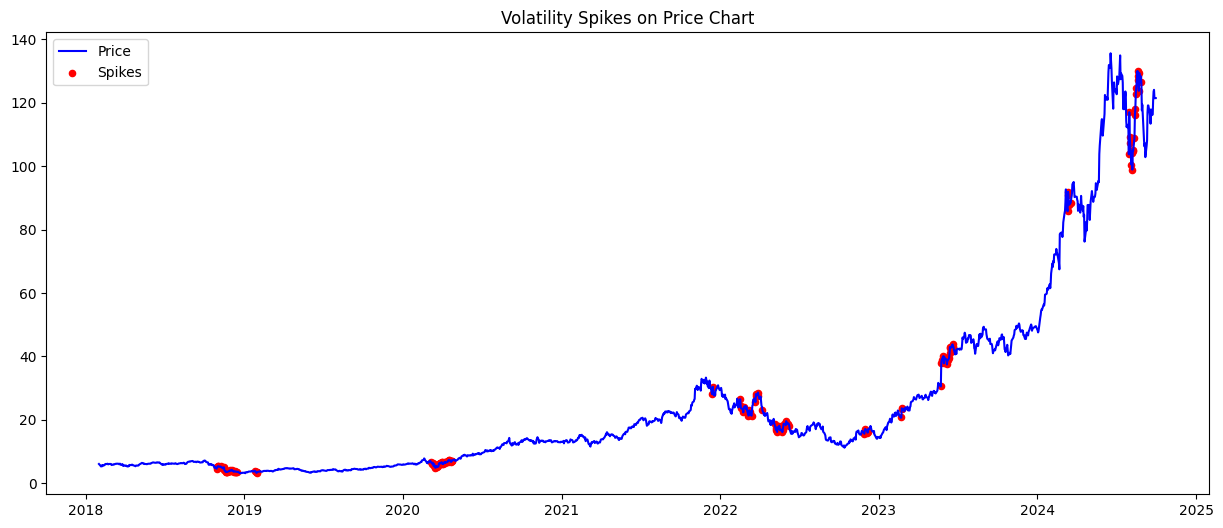

In [32]:
# Volatility Spikes
spikes = df[df["target"] == 1]

plt.figure(figsize=(15,6))

plt.plot(df.index, df["Adj Close"], label="Price", color="blue")
plt.scatter(spikes.index, spikes["Adj Close"], color="red", label="Spikes", s=20)

plt.title("Volatility Spikes on Price Chart")
plt.legend()
plt.show()

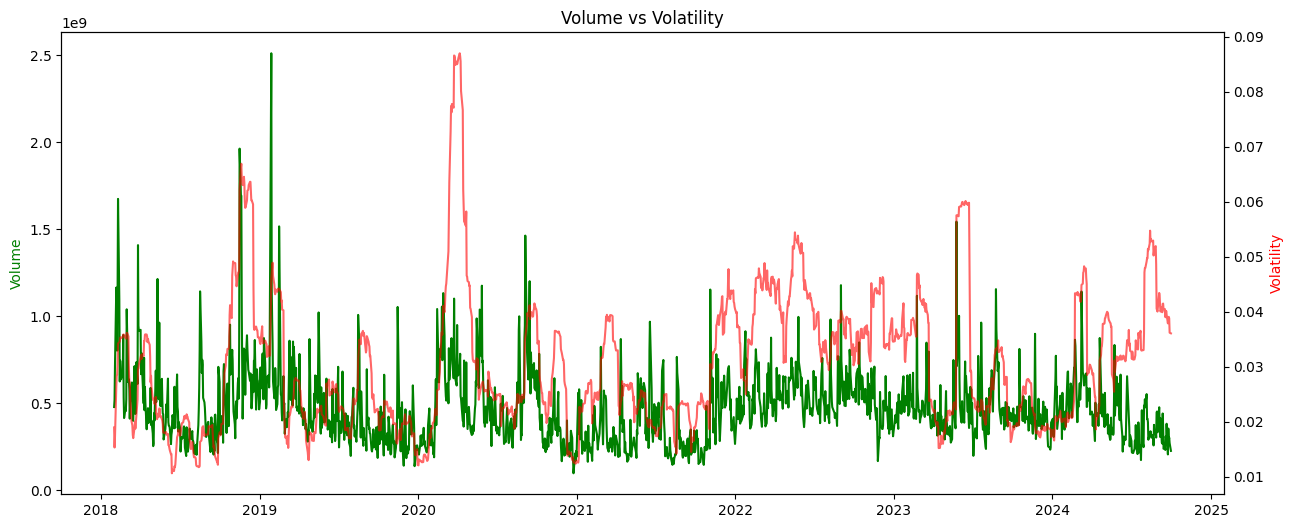

In [33]:
# Volume vs Volatility
fig, ax1 = plt.subplots(figsize=(15,6))

ax1.plot(df.index, df["Volume"], color="green")
ax1.set_ylabel("Volume", color="green")

ax2 = ax1.twinx()
ax2.plot(df.index, df["volatility"], color="red", alpha=0.6)
ax2.set_ylabel("Volatility", color="red")

plt.title("Volume vs Volatility")
plt.show()

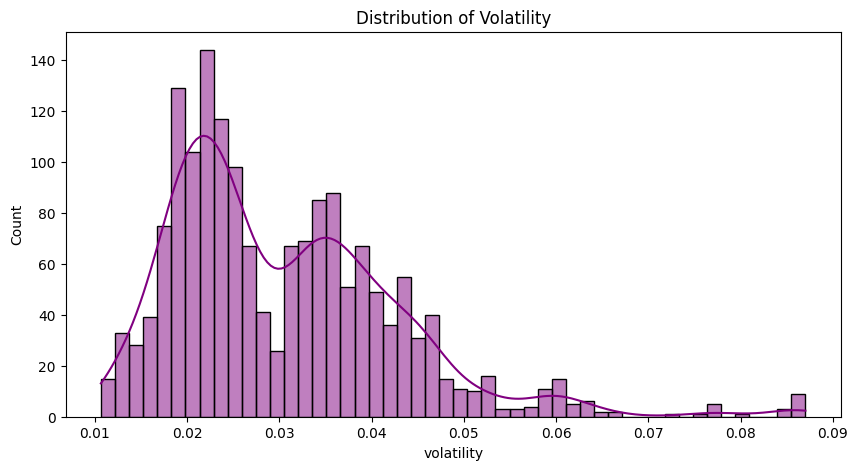

In [34]:
# Distribution of Volatility
plt.figure(figsize=(10,5))
sns.histplot(df["volatility"], bins=50, kde=True, color="purple")

plt.title("Distribution of Volatility")
plt.show()

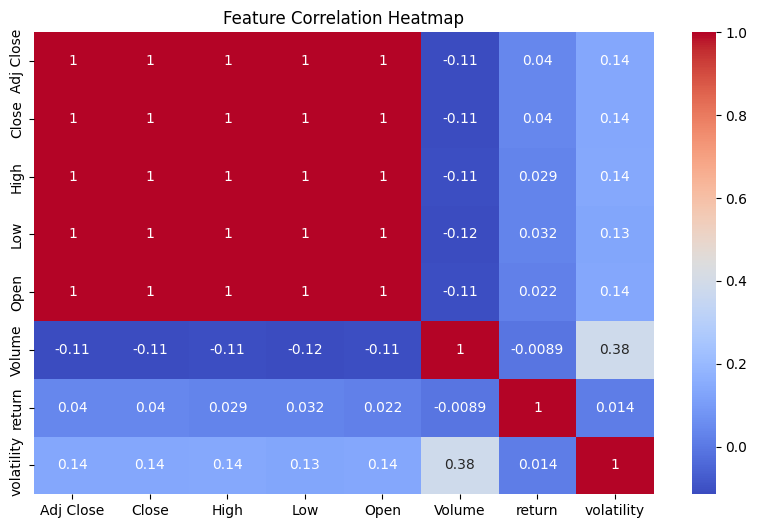

In [35]:
# Correlation Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(df[[
    "Adj Close",
    "Close",
    "High",
    "Low",
    "Open",
    "Volume",
    "return",
    "volatility"
]].corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

In [36]:
train = df[df.index < "2022-01-01"]
test  = df[df.index >= "2022-01-01"]

In [39]:
df.head()

,Adj Close,Close,High,Low,Open,Volume,day_of_week,month,day,week_of_year,return,volatility,target
Date,,,,,,,,,,,,,
2018-01-31,6.078580,6.1450,6.23175,6.11125,6.14425,4.785760e+08,2,1,31,5,0.012690,0.018992,0
2018-02-01,5.947512,6.0125,6.17250,5.95150,5.96300,5.192240e+08,3,2,1,5,-0.021562,0.015345,0
2018-02-02,5.774898,5.8380,5.94925,5.77925,5.92500,7.184640e+08,4,2,2,5,-0.029023,0.017265,0
2018-02-05,5.284754,5.3425,5.83075,5.12500,5.67500,1.165204e+09,0,2,5,6,-0.084875,0.026379,0
2018-02-06,5.578543,5.6395,5.64250,5.10000,5.11000,1.114800e+09,1,2,6,6,0.055592,0.028418,0


In [40]:
features = [
    "Adj Close",
    "High",
    "Low",
    "Open",
    "Volume",
    "day_of_week",
    "month",
    "day",
    "week_of_year",
    "return",
    "volatility"
]

X = df[features]
y = df["target"]

In [41]:
X_train = train[features]
y_train = train["target"]

X_test = test[features]
y_test = test["target"]

In [43]:
df.columns = df.columns.str.replace(" ", "_")

In [37]:
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score

In [44]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.5,
    num_leaves=31,
    random_state=42
)

lgb_model.fit(X_train,y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 73, number of negative: 915
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000153 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1889
[LightGBM] [Info] Number of data points in the train set: 988, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.073887 -> initscore=-2.528465
[LightGBM] [Info] Start training from score -2.528465
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

LGBMClassifier(learning_rate=0.5, n_estimators=500, random_state=42)

In [46]:
y_pred = lgb_model.predict(X_test)
y_prob = lgb_model.predict_proba(X_test)[:, 1]

In [47]:
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       594
           1       0.93      0.71      0.80        95

    accuracy                           0.95       689
   macro avg       0.94      0.85      0.89       689
weighted avg       0.95      0.95      0.95       689

ROC-AUC: 0.9716108452950557


In [49]:
import joblib

joblib.dump(lgb_model, "volatility_model.pkl")

features = [
    "Adj Close",
    "High",
    "Low",
    "Open",
    "Volume",
    "day_of_week",
    "month",
    "day",
    "week_of_year",
    "return",
    "volatility"
]

joblib.dump(features, "features.pkl")

model = joblib.load("volatility_model.pkl")
features = joblib.load("features.pkl")